<a href="https://colab.research.google.com/github/PujanPandey07/Deep-Learning-/blob/main/MLP/Mnist_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Hand Written Digit classification


In [1]:
import torch
import torch.nn as nn
import tensorflow
from tensorflow import keras

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train=X_train/255
X_test=X_test/255

In [4]:
X_train.shape


(60000, 28, 28)

In [12]:
#definition of my class
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.fc1=nn.Linear(784,128) # Changed from 758 to 784
    self.fc2=nn.Linear(128,64)
    self.fc3=nn.Linear(64,10)
  def forward(self, x):
        # MNIST images are (Batch, 1, 28, 28).
        # We need to flatten them to (Batch, 784)
        x = x.view(-1, 784)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # No activation on last layer (CrossEntropyLoss handles it)
        return x

In [13]:
Model_net=NeuralNetwork()

In [7]:
Model_net.state_dict()

OrderedDict([('fc1.weight',
              tensor([[-0.0166,  0.0088, -0.0186,  ..., -0.0131,  0.0216, -0.0180],
                      [ 0.0291, -0.0210,  0.0138,  ...,  0.0209,  0.0196,  0.0148],
                      [ 0.0180,  0.0038,  0.0334,  ..., -0.0212,  0.0300,  0.0256],
                      ...,
                      [ 0.0014, -0.0052,  0.0197,  ...,  0.0247,  0.0195,  0.0034],
                      [ 0.0352, -0.0135,  0.0058,  ..., -0.0030,  0.0308, -0.0070],
                      [ 0.0119, -0.0310, -0.0217,  ...,  0.0204,  0.0226,  0.0053]])),
             ('fc1.bias',
              tensor([ 2.8254e-02,  9.3037e-03,  3.5315e-02, -3.0752e-02,  3.1448e-02,
                      -3.5916e-03,  1.1758e-03, -9.7384e-03,  1.2281e-02, -3.3450e-02,
                      -9.9243e-03, -3.2106e-02,  1.2864e-03,  2.3603e-02, -1.0004e-02,
                       1.1032e-02, -8.4430e-03, -2.3073e-02, -2.7175e-02,  2.2757e-02,
                       3.2501e-02,  2.1029e-02, -3.3466e-02, -9.

In [21]:
# Trainning
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
torch.manual_seed(44)
epochs=35
loss_fn=nn.CrossEntropyLoss()
optimizer = optim.Adam(Model_net.parameters(), lr=0.001)
training_loss_values=[]
test_loss_values=[]
epoch_count=[]
for epoch in range(epochs):
  Model_net.train()
  # Convert X_train and y_train to PyTorch tensors
  X_train_tensor = torch.tensor(X_train).float()
  y_train_tensor = torch.tensor(y_train).long()

  y_pred=Model_net(X_train_tensor)
  loss=loss_fn(y_pred, y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  Model_net.eval()
  with torch.inference_mode():
      # Convert X_test and y_test to PyTorch tensors
      X_test_tensor = torch.tensor(X_test).float()
      y_test_tensor = torch.tensor(y_test).long() # CrossEntropyLoss expects long for target

      test_pred = Model_net(X_test_tensor)
      test_loss = loss_fn(test_pred, y_test_tensor) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Corrected: Remove the inner loop, append and print once per epoch
      epoch_count.append(epoch)
      training_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | Cross entropy: {loss} | Cross Entropy Test Loss: {test_loss} ")

Epoch: 0 | Cross entropy: 1.1874568462371826 | Cross Entropy Test Loss: 1.1070349216461182 
Epoch: 1 | Cross entropy: 1.1237273216247559 | Cross Entropy Test Loss: 1.045393466949463 
Epoch: 2 | Cross entropy: 1.0626081228256226 | Cross Entropy Test Loss: 0.986566424369812 
Epoch: 3 | Cross entropy: 1.0041773319244385 | Cross Entropy Test Loss: 0.9308542013168335 
Epoch: 4 | Cross entropy: 0.9486629366874695 | Cross Entropy Test Loss: 0.8784194588661194 
Epoch: 5 | Cross entropy: 0.8962745666503906 | Cross Entropy Test Loss: 0.8293717503547668 
Epoch: 6 | Cross entropy: 0.8472086787223816 | Cross Entropy Test Loss: 0.7837720513343811 
Epoch: 7 | Cross entropy: 0.8015574812889099 | Cross Entropy Test Loss: 0.7416768074035645 
Epoch: 8 | Cross entropy: 0.7593483924865723 | Cross Entropy Test Loss: 0.7030730247497559 
Epoch: 9 | Cross entropy: 0.7205297946929932 | Cross Entropy Test Loss: 0.6678558588027954 
Epoch: 10 | Cross entropy: 0.6849653124809265 | Cross Entropy Test Loss: 0.6357801

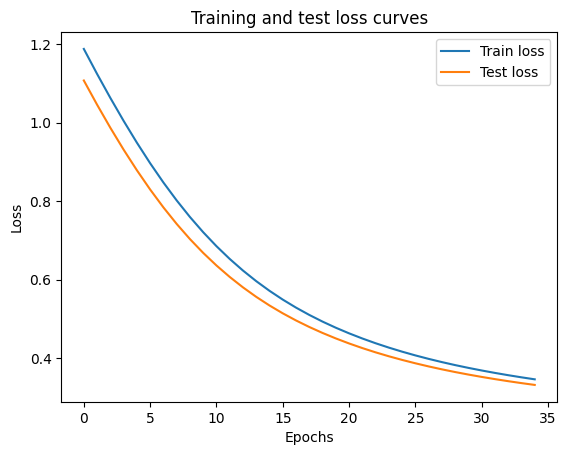

In [22]:
# Plot the loss curves
plt.plot(epoch_count, training_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();